In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 5.7 MB/s  0:00:015.8 MB/s eta 0:00:01:01


In [3]:
import pandas as pd


In [4]:
df = pd.read_csv('/Users/kanangoylarov/Downloads/CSV Files/train/UNSW_NB15_training-set.csv')
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [5]:
attacks = df[df['label'] == 1]
# Yöntem 2: attack_cat sütununa göre
attacks = df[df['attack_cat'] != 'Normal']

print(f"Toplam kayıt: {len(df)}")
print(f"Normal kayıt: {len(df[df['label'] == 0])}")
print(f"Attack kayıt: {len(attacks)}")
print(f"\nAttack kategorileri:\n{attacks['attack_cat'].value_counts()}")


Toplam kayıt: 175341
Normal kayıt: 56000
Attack kayıt: 119341

Attack kategorileri:
attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [6]:
df.columns


Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='str')

In [7]:
attack_mapping = {
    'Normal':         0,
    'Generic':        1,
    'Exploits':       2,
    'Fuzzers':        3,
    'DoS':            4,
    'Reconnaissance': 5,
    'Analysis':       6,
    'Backdoor':       7,
    'Shellcode':      8,
    'Worms':          9
}

df['attack_cat_encoded'] = df['attack_cat'].map(attack_mapping)
print(df[['attack_cat', 'attack_cat_encoded']].drop_duplicates().sort_values('attack_cat_encoded'))

            attack_cat  attack_cat_encoded
0               Normal                   0
117204         Generic                   1
48932         Exploits                   2
48017          Fuzzers                   3
48999              DoS                   4
48866   Reconnaissance                   5
47932         Analysis                   6
47911         Backdoor                   7
48813        Shellcode                   8
49959            Worms                   9


In [8]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,attack_cat_encoded
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,0,0,0,1,1,0,Normal,0,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,2,0,0,0,1,6,0,Normal,0,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,3,0,0,0,2,6,0,Normal,0,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,3,1,1,0,2,1,0,Normal,0,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,40,0,0,0,2,39,0,Normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,24,0,0,0,24,24,0,Generic,1,1
175337,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,...,2,0,0,0,1,1,0,Shellcode,1,8
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,0,0,0,3,12,0,Generic,1,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,30,0,0,0,30,30,0,Generic,1,1


In [9]:
df = df.drop('attack_cat', axis=1)
print(df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label', 'attack_cat_encoded']


In [10]:
df = df.rename(columns={'attack_cat_encoded': 'attack_cat'})

In [11]:
df.head


<bound method NDFrame.head of             id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0            1  0.121478   tcp       -   FIN      6      4     258     172   
1            2  0.649902   tcp       -   FIN     14     38     734   42014   
2            3  1.623129   tcp       -   FIN      8     16     364   13186   
3            4  1.681642   tcp     ftp   FIN     12     12     628     770   
4            5  0.449454   tcp       -   FIN     10      6     534     268   
...        ...       ...   ...     ...   ...    ...    ...     ...     ...   
175336  175337  0.000009   udp     dns   INT      2      0     114       0   
175337  175338  0.505762   tcp       -   FIN     10      8     620     354   
175338  175339  0.000009   udp     dns   INT      2      0     114       0   
175339  175340  0.000009   udp     dns   INT      2      0     114       0   
175340  175341  0.000009   udp     dns   INT      2      0     114       0   

                 rate  ...  ct_ds

In [12]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,attack_cat
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,0,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,0,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,0,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,0,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,0,0


In [13]:
df['proto'].value_counts()

proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
rdp          98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64

In [14]:
print(df.select_dtypes(include=['object']).columns.tolist())


['proto', 'service', 'state']


/var/folders/f7/yk2hddkx4gv4yjgq3h8kr__c0000gn/T/ipykernel_13195/1905992068.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns.tolist())


In [15]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique değer → {df[col].unique()[:5]}")

proto: 133 unique değer → <StringArray>
['tcp', 'udp', 'arp', 'ospf', 'icmp']
Length: 5, dtype: str
service: 13 unique değer → <StringArray>
['-', 'ftp', 'smtp', 'snmp', 'http']
Length: 5, dtype: str
state: 9 unique değer → <StringArray>
['FIN', 'INT', 'CON', 'ECO', 'REQ']
Length: 5, dtype: str


/var/folders/f7/yk2hddkx4gv4yjgq3h8kr__c0000gn/T/ipykernel_13195/472296847.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [16]:
from sklearn.preprocessing import LabelEncoder


In [17]:
le = LabelEncoder()
for col in ['proto', 'service', 'state']:
    df[col] = le.fit_transform(df[col])

print(df[['proto', 'service', 'state']].head())


   proto  service  state
0    113        0      2
1    113        0      2
2    113        0      2
3    113        3      2
4    113        0      2


In [18]:
!brew install libomp

⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠙ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠙ JSON API cask.jws.json                             Downloading  15.4MB/-------⠚ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠚ JSON API cask.jws.json                             Downloading  15.4MB/-------⠚ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠚ JSON API cask.jws.json                             Downloading  15.4MB/-------⠞ JSON API formula.jws.json       

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
X = df.drop(['label', 'attack_cat'], axis=1)
y = df[['label']]  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)


In [24]:
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier

In [25]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

[0]	validation_0-logloss:0.54087
[10]	validation_0-logloss:0.19682
[20]	validation_0-logloss:0.10438
[30]	validation_0-logloss:0.07132


/Users/kanangoylarov/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:33:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[40]	validation_0-logloss:0.05624
[50]	validation_0-logloss:0.04790
[60]	validation_0-logloss:0.04305
[70]	validation_0-logloss:0.03990
[80]	validation_0-logloss:0.03549
[90]	validation_0-logloss:0.03288
[99]	validation_0-logloss:0.03046


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

# Genel özet
print(classification_report(y_test, y_pred))

# Sadece accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11169
           1       0.99      1.00      0.99     23900

    accuracy                           0.99     35069
   macro avg       0.99      0.98      0.99     35069
weighted avg       0.99      0.99      0.99     35069

Accuracy: 0.9887079757050387


In [27]:
import pickle

# Modeli kaydet
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model kaydedildi!")

Model kaydedildi!


In [28]:
df.columns


Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label', 'attack_cat'],
      dtype='str')

In [29]:
df


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,attack_cat
0,1,0.121478,113,0,2,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,0,0
1,2,0.649902,113,0,2,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,0,0
2,3,1.623129,113,0,2,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,0,0
3,4,1.681642,113,3,2,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,0,0
4,5,0.449454,113,0,2,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,119,2,3,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,1,1
175337,175338,0.505762,113,0,2,10,8,620,354,33.612649,...,1,2,0,0,0,1,1,0,1,8
175338,175339,0.000009,119,2,3,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,1,1
175339,175340,0.000009,119,2,3,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,1,1


In [30]:
X_train

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
96203,96204,0.518188,113,5,2,10,8,794,1158,32.806626,...,3,3,1,5,0,0,1,3,5,0
58960,58961,0.000009,120,0,3,2,0,200,0,111111.107200,...,3,3,3,4,0,0,0,3,4,0
65069,65070,0.919013,113,0,2,18,12,6070,678,31.555592,...,1,1,1,5,0,0,0,1,5,0
64133,64134,1.003319,113,5,2,10,10,762,4220,18.937147,...,1,1,1,1,0,0,0,1,1,0
111445,111446,0.000005,62,0,3,2,0,200,0,200000.005100,...,3,1,1,5,0,0,0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,119880,0.000005,119,2,3,2,0,114,0,200000.005100,...,32,32,16,38,0,0,0,33,38,0
103694,103695,4.449357,113,3,2,24,22,1272,1634,10.113821,...,2,1,1,2,1,1,0,3,1,0
131932,131933,0.000008,119,2,3,2,0,114,0,125000.000300,...,16,16,16,33,0,0,0,16,33,0
146867,146868,0.000004,119,2,3,2,0,114,0,250000.000600,...,36,36,23,36,0,0,0,37,36,0


In [31]:
X = df
y = df
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
X_train_attacks = X_train[y_train['attack_cat'] != 0]
y_train_attacks = y_train['attack_cat'][y_train['attack_cat'] != 0]


In [33]:
X_test_attacks = X_test[y_test['attack_cat'] != 0]
y_test_attacks = y_test['attack_cat'][y_test['attack_cat'] != 0]

# Normalize et (autoencoder için şart)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_attacks)
X_test_scaled = scaler.transform(X_test_attacks)

In [ ]:
!pip install conda

In [ ]:
!conda create -n tf_env python=3.12
!conda activate tf_env
!pip install tensorflow

In [ ]:
!pip install tensorflow

In [ ]:
import subprocess
import sys

# Miniconda python'una ipykernel yukle
subprocess.run([
    "/Users/kanangoylarov/miniconda3/bin/python",
    "-m", "pip", "install", "ipykernel"
], check=True)

# Kernel olarak kaydet
subprocess.run([
    "/Users/kanangoylarov/miniconda3/bin/python",
    "-m", "ipykernel", "install",
    "--user", "--name", "miniconda3",
    "--display-name", "Python (miniconda3)"
], check=True)

print("Tamamdı! Şimdi kernel'ı değiştir.")

In [ ]:
import subprocess
subprocess.check_call(["/Users/kanangoylarov/miniconda3/bin/python", "-m", "pip", "install", "scikit-learn"])

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_attacks)
X_test_scaled = scaler.transform(X_test_attacks)

In [35]:
import tensorflow as tf
from tensorflow import keras

input_dim = X_train_scaled.shape[1]

input_layer = keras.layers.Input(shape=(input_dim,))
x = keras.layers.Dense(128, activation='relu')(input_layer)
x = keras.layers.Dense(64, activation='relu')(x)
bottleneck = keras.layers.Dense(32, activation='relu')(x)

# Decoder
x = keras.layers.Dense(64, activation='relu')(bottleneck)
x = keras.layers.Dense(128, activation='relu')(x)
output_layer = keras.layers.Dense(input_dim, activation='linear')(x)

autoencoder = keras.Model(input_layer, output_layer)
encoder = keras.Model(input_layer, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')


In [36]:
autoencoder.fit(
    X_train_scaled, X_train_scaled,  # Input = Output
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - loss: 0.1532 - val_loss: 0.1537
Epoch 2/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - loss: 0.0536 - val_loss: 0.1009
Epoch 3/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - loss: 0.0372 - val_loss: 0.1007
Epoch 4/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - loss: 0.0434 - val_loss: 0.0544
Epoch 5/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - loss: 0.0278 - val_loss: 0.0344
Epoch 6/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - loss: 0.0208 - val_loss: 0.0502
Epoch 7/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - loss: 0.0430 - val_loss: 0.0335
Epoch 8/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - loss: 0.0325 - val_loss: 0.1185
Epoch 9/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - loss: 0.0373 - val_loss: 0.0349
Epoch 10/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - loss: 0.0327 - val_loss: 0.1135
Epoch 11/50
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - loss: 0.0418 - val_loss: 0.0787
Epoch 12

In [37]:
X_train_encoded = encoder.predict(X_train_scaled)  # (N, 43) → (N, 32)
X_test_encoded = encoder.predict(X_test_scaled)

print(f"Önce: {X_train_scaled.shape}")
print(f"Sonra: {X_train_encoded.shape}")

2983/2983 ━━━━━━━━━━━━━━━━━━━━ 1s 213us/step
747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 211us/step
Önce: (95441, 45)
Sonra: (95441, 32)


In [38]:
num_classes = y_train_attacks.nunique()

classifier = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(32,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# y değerlerini 0'dan başlat
from sklearn.preprocessing import LabelEncoder
le_cat = LabelEncoder()
y_train_encoded = le_cat.fit_transform(y_train_attacks)
y_test_encoded = le_cat.transform(y_test_attacks)

classifier.fit(
    X_train_encoded, y_train_encoded,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30


/Users/kanangoylarov/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.8082 - loss: 0.6032 - val_accuracy: 0.9560 - val_loss: 0.2051
Epoch 2/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.9424 - loss: 0.2016 - val_accuracy: 0.9758 - val_loss: 0.0916
Epoch 3/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step - accuracy: 0.9611 - loss: 0.1288 - val_accuracy: 0.9833 - val_loss: 0.0605
Epoch 4/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.9679 - loss: 0.1030 - val_accuracy: 0.9845 - val_loss: 0.0535
Epoch 5/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.9739 - loss: 0.0841 - val_accuracy: 0.9900 - val_loss: 0.0413
Epoch 6/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.9778 - loss: 0.0701 - val_accuracy: 0.9901 - val_loss: 0.0335
Epoch 7/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.9793 - loss: 0.0667 - val_accuracy: 0.9892 - val_loss: 0.0332
Epoch 8/30
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - accuracy: 0.9826 - loss: 0.05

In [40]:
def predict_pipeline(X_input):
    # label ve attack_cat sütunlarını çıkar
    cols_to_drop = [c for c in ['label', 'attack_cat', 'attack_cat_encoded'] if c in X_input.columns]
    X_input = X_input.drop(cols_to_drop, axis=1)
    
    # 1. XGBoost: Normal mi Attack mı?
    is_attack = model.predict(X_input)[0]
    
    if not is_attack:
        return {'label': 0, 'attack_cat': 'Normal'}
    
    # 2. Normalize
    X_scaled = scaler.transform(X_input)
    
    # 3. Encoder ile sıkıştır
    X_encoded = encoder.predict(X_scaled, verbose=0)
    
    # 4. Classifier ile hangi tip?
    probs = classifier.predict(X_encoded, verbose=0)
    attack_type = le_cat.inverse_transform([probs.argmax(axis=1)[0]])[0]
    
    attack_names = {
        1: 'Generic', 2: 'Exploits', 3: 'Fuzzers',
        4: 'DoS', 5: 'Reconnaissance', 6: 'Analysis',
        7: 'Backdoor', 8: 'Shellcode', 9: 'Worms'
    }
    
    return {
        'label': 1,
        'attack_cat': attack_names.get(attack_type, 'Unknown')
    }

# Test et
sample = df.iloc[0:1]  # X_test yerine df'den al
print(predict_pipeline(sample))

{'label': 0, 'attack_cat': 'Normal'}


In [41]:
preds_cat = classifier.predict(X_test_encoded).argmax(axis=1)

print(classification_report(
    y_test_encoded, preds_cat,
    target_names=[str(c) for c in le_cat.classes_]
))

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      8079
           2       1.00      1.00      1.00      6772
           3       0.99      1.00      1.00      3570
           4       1.00      0.99      1.00      2370
           5       1.00      1.00      1.00      2098
           6       0.99      1.00      0.99       393
           7       0.99      0.99      0.99       360
           8       0.99      1.00      0.99       233
           9       0.95      0.76      0.84        25

    accuracy                           1.00     23900
   macro avg       0.99      0.97      0.98     23900
weighted avg       1.00      1.00      1.00     23900



In [42]:
import pickle

# XGBoost'u kaydet
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Autoencoder ve Classifier'ı kaydet
encoder.save('encoder.keras')
classifier.save('classifier.keras')

# Scaler ve LabelEncoder'ı kaydet
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('le_cat.pkl', 'wb') as f:
    pickle.dump(le_cat, f)

print("Tüm modeller kaydedildi!")

Tüm modeller kaydedildi!


In [44]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.3 MB/s  0:00:023.2 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.9 MB/s  0:00:00m 4.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.9 MB/s  0:00:005.0 MB/s eta 0:00:01:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [46]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [52]:
print(f"X_train columns: {len(X_train.columns)}")
print(f"feature_importances_ length: {len(model.feature_importances_)}")

X_train columns: 45
feature_importances_ length: 43


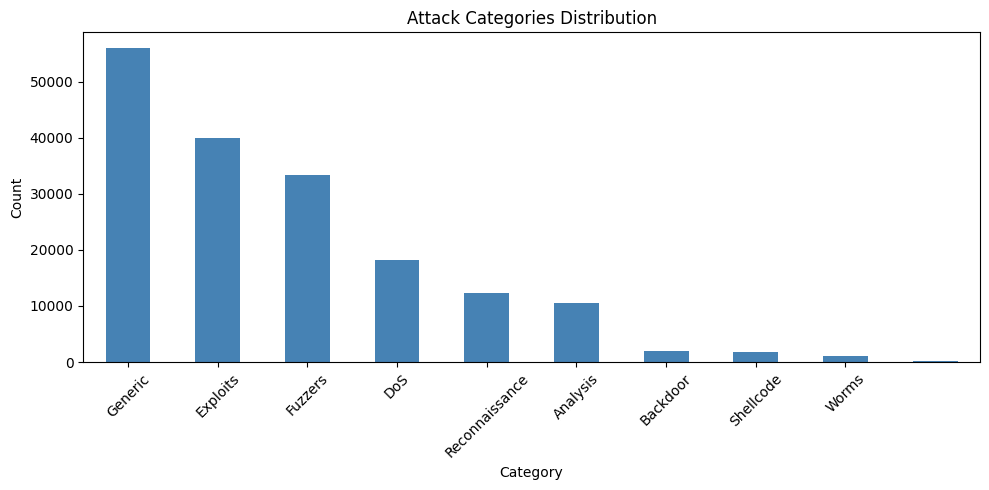

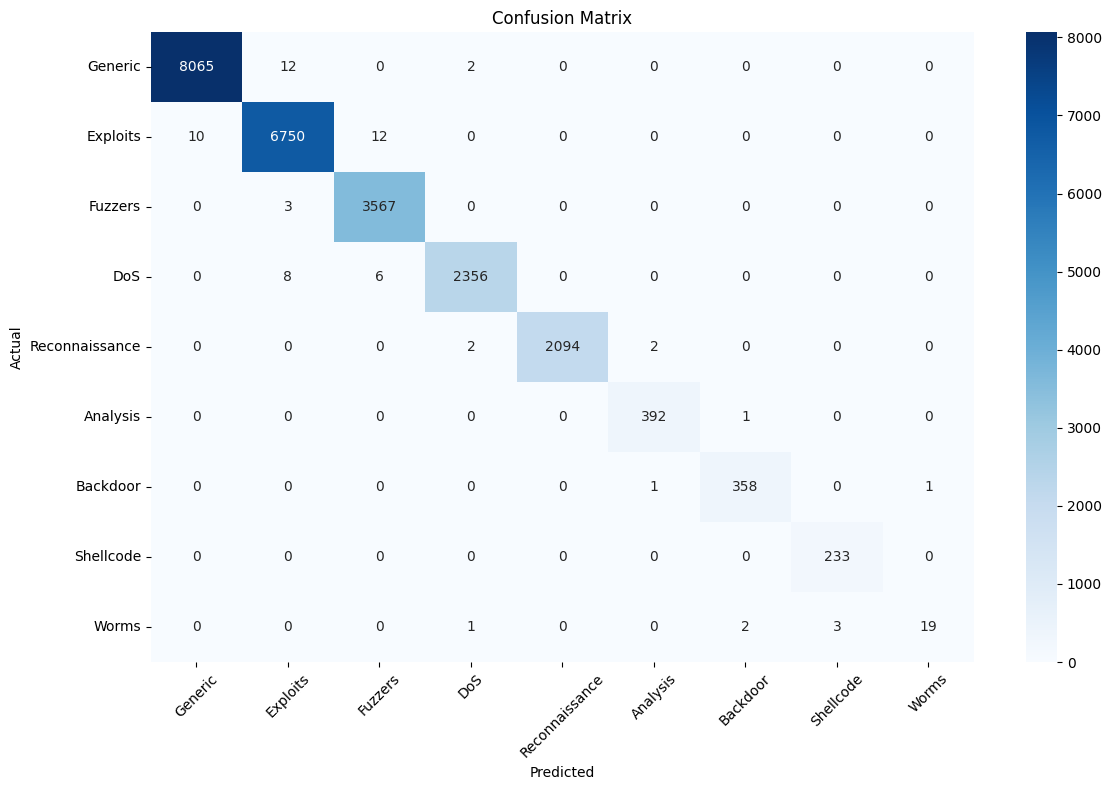

/var/folders/f7/yk2hddkx4gv4yjgq3h8kr__c0000gn/T/ipykernel_13195/869903875.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


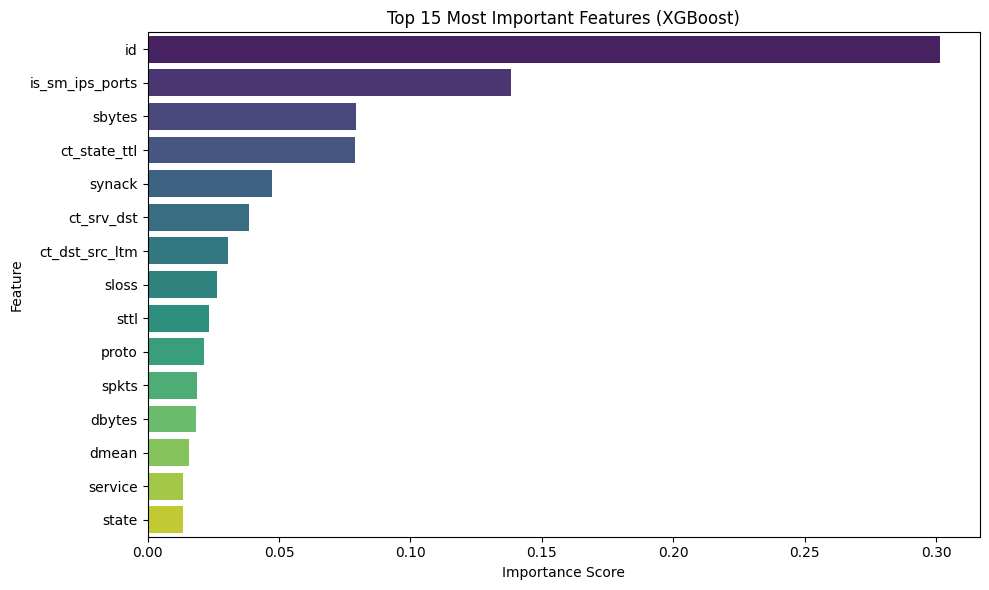

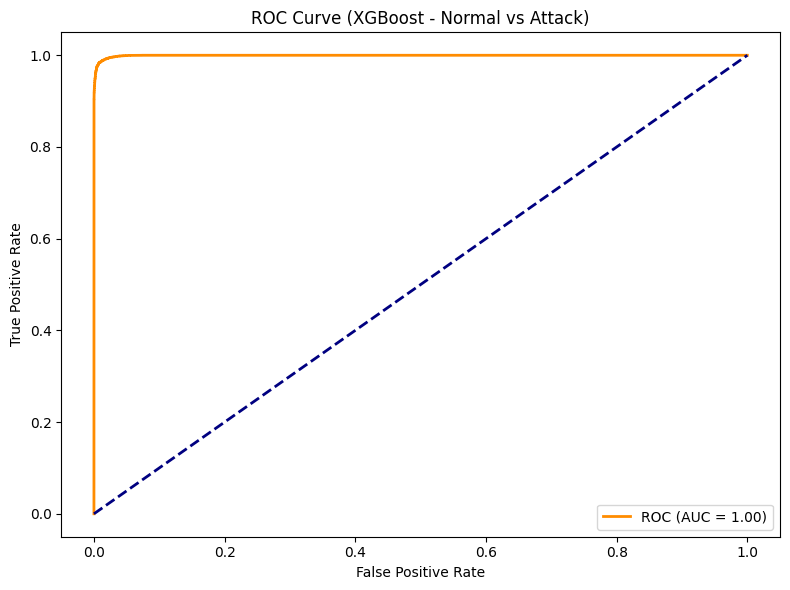

✅ All charts saved successfully!


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

attack_names = ['Generic', 'Exploits', 'Fuzzers', 'DoS', 
                'Reconnaissance', 'Analysis', 'Backdoor', 'Shellcode', 'Worms']

# ---- 1. ATTACK CATEGORIES DISTRIBUTION ----
plt.figure(figsize=(10, 5))
df['attack_cat'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Attack Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(ticks=range(len(attack_names)), labels=attack_names, rotation=45)
plt.tight_layout()
plt.savefig('attack_distribution.png')
plt.show()

# ---- 2. CONFUSION MATRIX ----
preds_cat = classifier.predict(X_test_encoded, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test_attacks, le_cat.inverse_transform(preds_cat))

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=attack_names,
            yticklabels=attack_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ---- 3. FEATURE IMPORTANCE ----
import pandas as pd

feature_names = model.get_booster().feature_names

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
# ---- 4. ROC CURVE ----
X_test_clean = X_test.drop(['label', 'attack_cat'], axis=1, errors='ignore')

y_prob = model.predict_proba(X_test_clean)[:, 1]
fpr, tpr, _ = roc_curve(y_test['label'], y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost - Normal vs Attack)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

print("✅ All charts saved successfully!")

In [57]:
from sklearn.manifold import TSNE

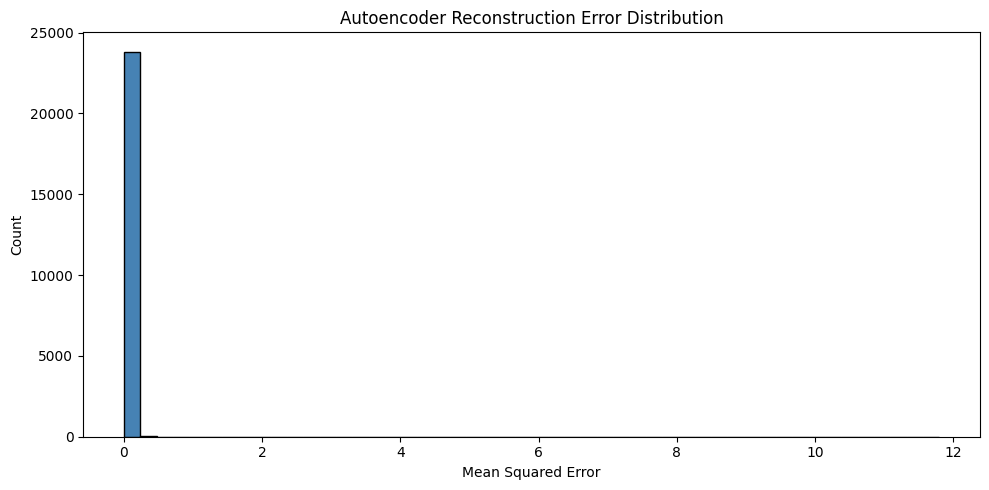

/var/folders/f7/yk2hddkx4gv4yjgq3h8kr__c0000gn/T/ipykernel_13195/769717026.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_df, x='attack_name', y='error', palette='Set2')


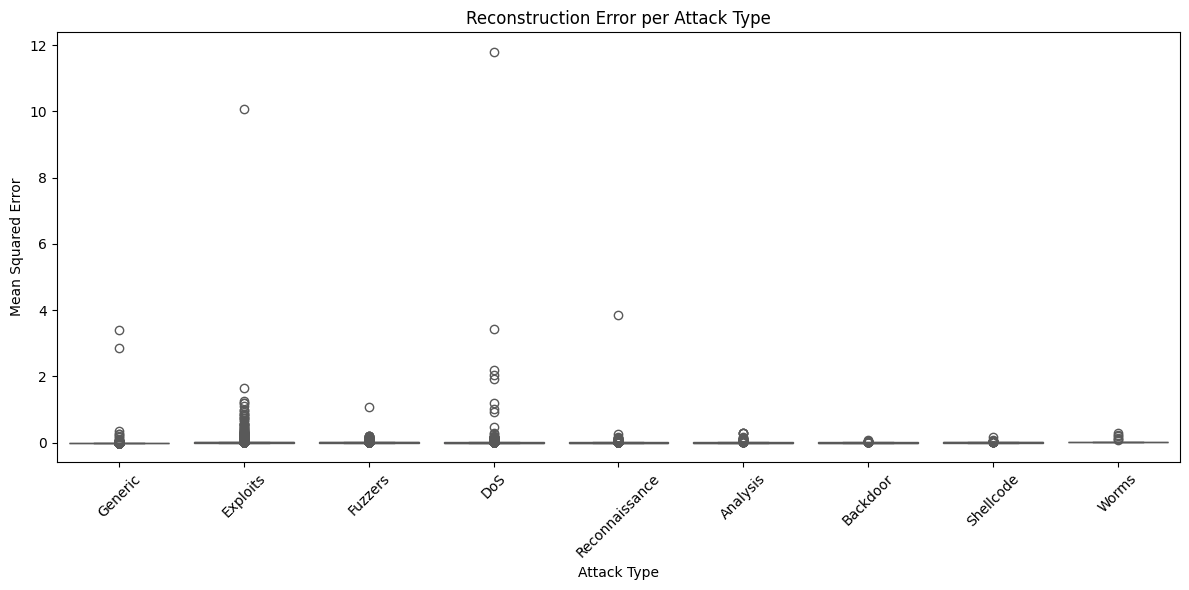

Running t-SNE...


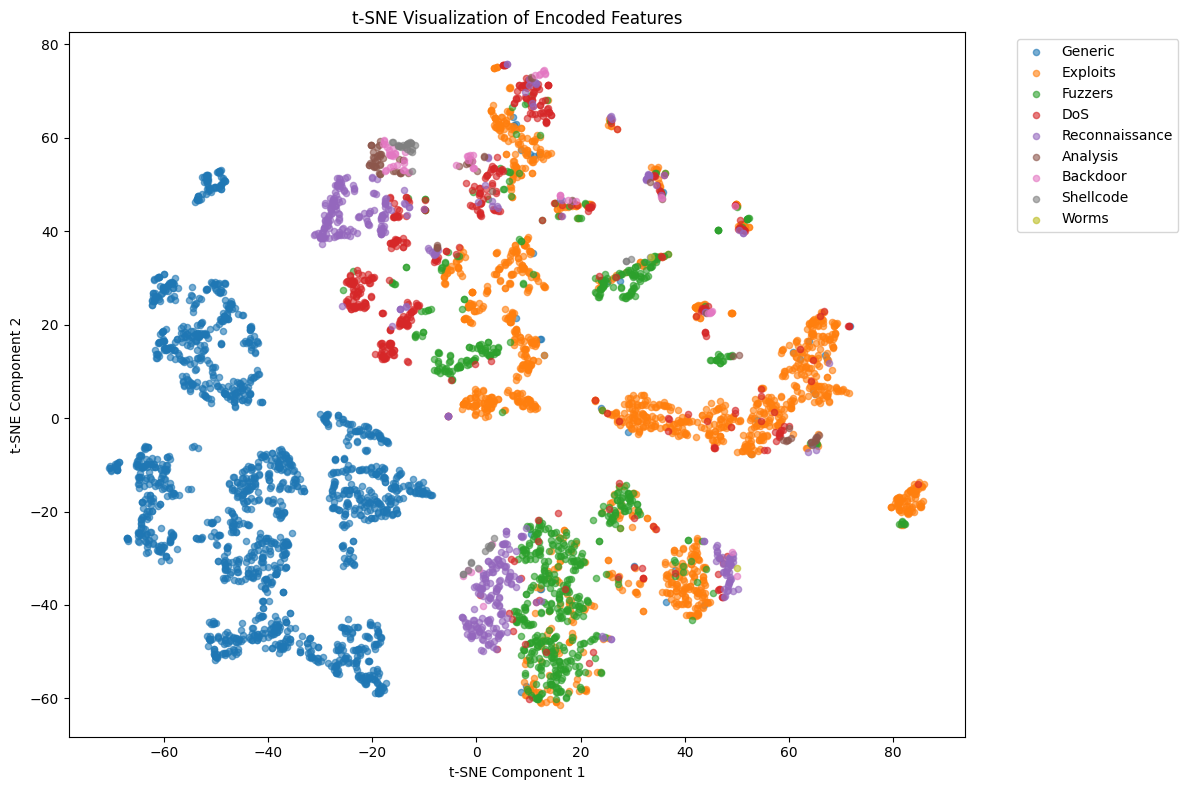

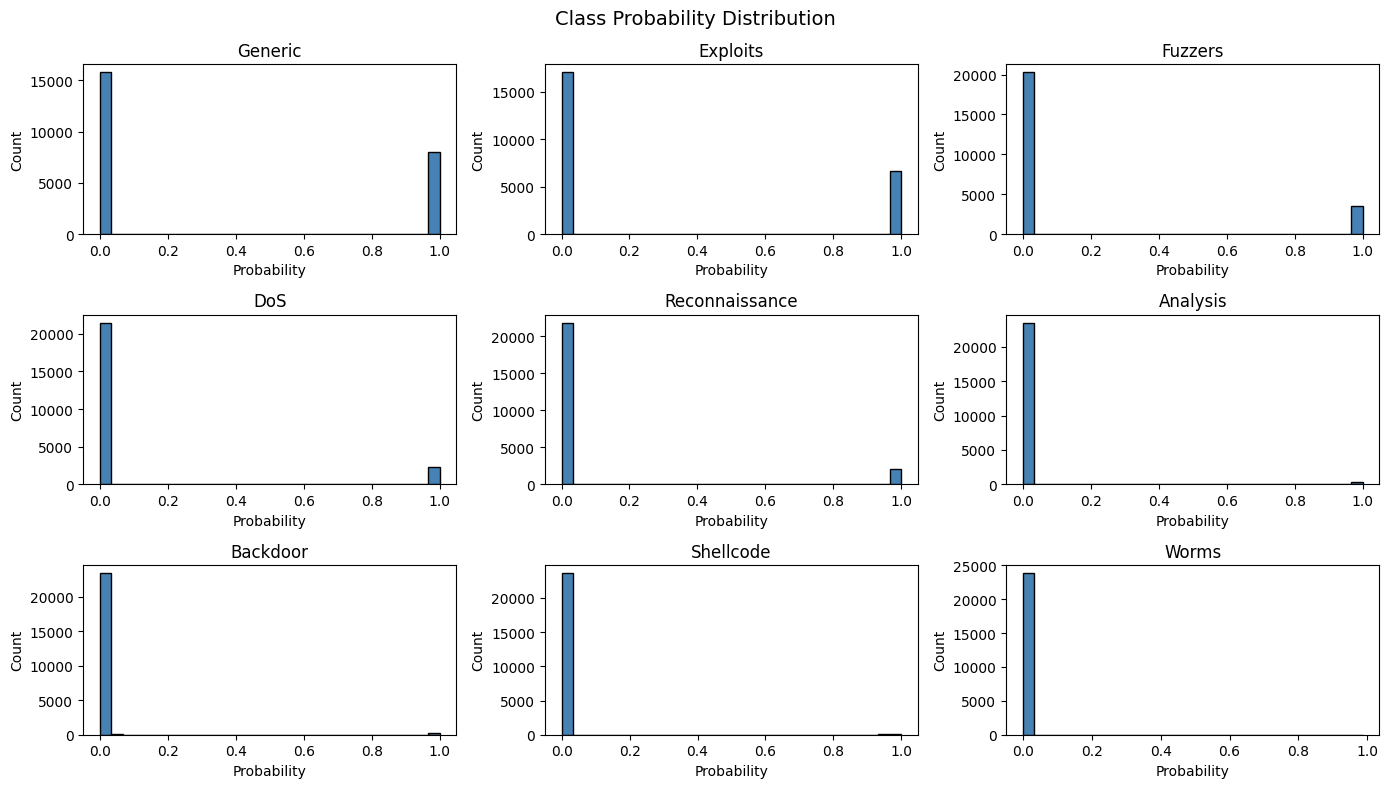

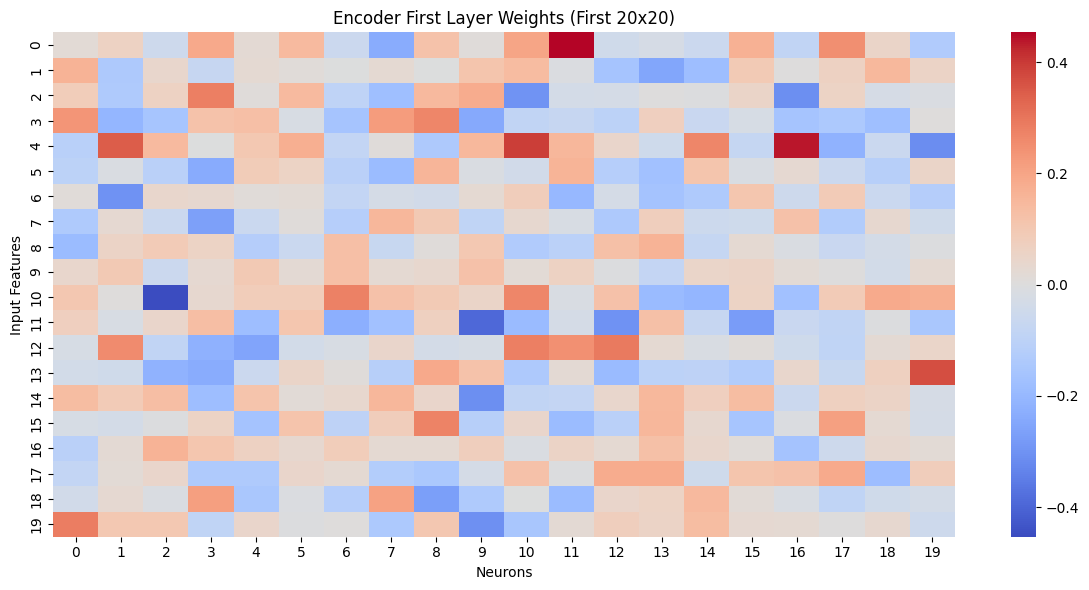

✅ All charts saved!


In [59]:
attack_names = {
    1: 'Generic', 2: 'Exploits', 3: 'Fuzzers', 4: 'DoS',
    5: 'Reconnaissance', 6: 'Analysis', 7: 'Backdoor', 
    8: 'Shellcode', 9: 'Worms'
}

# ---- 1. AUTOENCODER RECONSTRUCTION ERROR (history yerine) ----
X_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)
reconstruction_errors = np.mean(np.square(X_test_scaled - X_reconstructed), axis=1)

plt.figure(figsize=(10, 5))
plt.hist(reconstruction_errors, bins=50, color='steelblue', edgecolor='black')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('reconstruction_error_dist.png')
plt.show()

# ---- 2. RECONSTRUCTION ERROR PER ATTACK TYPE ----
error_df = pd.DataFrame({
    'error': reconstruction_errors,
    'attack_cat': y_test_attacks.values
})
error_df['attack_name'] = error_df['attack_cat'].map(attack_names)

plt.figure(figsize=(12, 6))
sns.boxplot(data=error_df, x='attack_name', y='error', palette='Set2')
plt.title('Reconstruction Error per Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reconstruction_error_per_type.png')
plt.show()

# ---- 3. t-SNE ----
from sklearn.manifold import TSNE

print("Running t-SNE...")
sample_size = 5000
idx = np.random.choice(len(X_test_encoded), sample_size, replace=False)
X_sample = X_test_encoded[idx]
y_sample = y_test_attacks.values[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(12, 8))
for cat_id, cat_name in attack_names.items():
    mask = y_sample == cat_id
    if mask.sum() > 0:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   label=cat_name, alpha=0.6, s=20)
plt.title('t-SNE Visualization of Encoded Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('tsne_visualization.png')
plt.show()

# ---- 4. CLASS PROBABILITY DISTRIBUTION ----
probs = classifier.predict(X_test_encoded, verbose=0)

plt.figure(figsize=(14, 8))
for i, (cat_id, cat_name) in enumerate(attack_names.items()):
    plt.subplot(3, 3, i + 1)
    plt.hist(probs[:, i], bins=30, color='steelblue', edgecolor='black')
    plt.title(cat_name)
    plt.xlabel('Probability')
    plt.ylabel('Count')
plt.suptitle('Class Probability Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('probability_distribution.png')
plt.show()

# ---- 5. ENCODER LAYER WEIGHTS HEATMAP ----
encoder_weights = encoder.layers[1].get_weights()[0]  # İlk dense layer

plt.figure(figsize=(12, 6))
sns.heatmap(encoder_weights[:20, :20], cmap='coolwarm', center=0)
plt.title('Encoder First Layer Weights (First 20x20)')
plt.xlabel('Neurons')
plt.ylabel('Input Features')
plt.tight_layout()
plt.savefig('encoder_weights.png')
plt.show()

print("✅ All charts saved!")

In [61]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# Reconstruction
X_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)

# 1. MSE - Mean Squared Error
mse = mean_squared_error(X_test_scaled, X_reconstructed)

# 2. MAE - Mean Absolute Error
mae = mean_absolute_error(X_test_scaled, X_reconstructed)

# 3. RMSE
rmse = np.sqrt(mse)

# 4. R² Score (ne kadar iyi reconstruct ediyor)
ss_res = np.sum((X_test_scaled - X_reconstructed) ** 2)
ss_tot = np.sum((X_test_scaled - np.mean(X_test_scaled)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 5. Cosine Similarity (her örnek için)
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = np.mean([cosine_similarity([X_test_scaled[i]], [X_reconstructed[i]])[0][0] 
                   for i in range(len(X_test_scaled))])

print("=" * 50)
print("AUTOENCODER METRICS")
print("=" * 50)
print(f"MSE : {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")
print(f"Cosine Similarity: {cos_sim:.6f}")

AUTOENCODER METRICS
MSE : 0.006786
RMSE: 0.082376
MAE: 0.029135
R²: 0.993260
Cosine Similarity: 0.997968


In [62]:
import pandas as pd
import numpy as np

# Orijinal veriden istatistikleri al
original_data = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Her attack tipi için 2 örnek yarat
test_samples = []

for cat_id, cat_name in attack_names.items():
    # O kategoriye ait gerçek verilerin istatistiklerini al
    mask = y_test_attacks.values == cat_id
    if mask.sum() == 0:
        continue
    
    real_samples = X_test_scaled[mask]
    mean = real_samples.mean(axis=0)
    std = real_samples.std(axis=0)
    
    # Gerçekçi sentetik örnek üret (mean + küçük noise)
    synthetic = mean + np.random.normal(0, 0.1, mean.shape)
    
    test_samples.append({
        'attack_type': cat_name,
        'cat_id': cat_id,
        'data': synthetic
    })

print(f"✅ {len(test_samples)} test örneği yaratıldı!")

✅ 9 test örneği yaratıldı!


In [63]:
results = []

for sample in test_samples:
    X_input = sample['data'].reshape(1, -1)
    
    # Reconstruct
    X_recon = autoencoder.predict(X_input, verbose=0)
    
    # Encode
    X_enc = encoder.predict(X_input, verbose=0)
    
    # Classify
    probs = classifier.predict(X_enc, verbose=0)
    predicted_id = le_cat.inverse_transform([probs.argmax()])[0]
    confidence = probs.max()
    
    # Reconstruction error
    recon_error = mean_squared_error(X_input[0], X_recon[0])
    
    results.append({
        'True Attack': sample['attack_type'],
        'Predicted Attack': attack_names.get(predicted_id, 'Unknown'),
        'Correct': sample['attack_type'] == attack_names.get(predicted_id, 'Unknown'),
        'Confidence': f"{confidence*100:.1f}%",
        'Reconstruction Error': f"{recon_error:.6f}"
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   True Attack Predicted Attack  Correct Confidence Reconstruction Error
       Generic          Generic     True     100.0%             0.013151
      Exploits         Exploits     True     100.0%             0.124421
       Fuzzers          Fuzzers     True     100.0%             0.126327
           DoS              DoS     True     100.0%             0.073085
Reconnaissance   Reconnaissance     True     100.0%             0.158669
      Analysis         Analysis     True      97.6%             0.239611
      Backdoor        Shellcode    False      53.4%             0.078498
     Shellcode        Shellcode     True      99.6%             0.162922
         Worms            Worms     True      97.5%             0.089529


In [ ]:
# Threshold belirle (normal verinin max reconstruction error'u)
normal_errors = []
for i in range(len(X_test_scaled)):
    x = X_test_scaled[i].reshape(1, -1)
    x_recon = autoencoder.predict(x, verbose=0)
    error = mean_squared_error(x[0], x_recon[0])
    normal_errors.append(error)

threshold = np.percentile(normal_errors, 95)  # 95. percentile
print(f"Anomaly Threshold: {threshold:.6f}")

# Yeni örneği test et
for sample in test_samples:
    X_input = sample['data'].reshape(1, -1)
    X_recon = autoencoder.predict(X_input, verbose=0)
    error = mean_squared_error(X_input[0], X_recon[0])
    is_anomaly = error > threshold
    
    print(f"{sample['attack_type']:15} | Error: {error:.6f} | Anomaly: {'🚨 YES' if is_anomaly else '✅ NO'}")